#### Performing Feature Selaction on A Dataset

In [252]:
import pandas as pd
import numpy as np

In [253]:
df = pd.read_csv(r"c:\Users\user\Downloads\test.csv.zip")

In [254]:
df.shape

(2947, 563)

In [255]:
df["Activity"].value_counts()

Activity
LAYING                537
STANDING              532
WALKING               496
SITTING               491
WALKING_UPSTAIRS      471
WALKING_DOWNSTAIRS    420
Name: count, dtype: int64

In [256]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [257]:
#Separate Features and target
x=df.drop("Activity",axis=1)
y=df["Activity"]

#Encode target labels
le=LabelEncoder()
y=le.fit_transform(y)

In [258]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [259]:
print(x_train.shape)
print(x_test.shape)


(2357, 562)
(590, 562)


#### Applying Logistic Reg.....

In [260]:
log_reg=LogisticRegression(max_iter=1000)


In [261]:
log_reg.fit(x_train,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [262]:
#make pridiction on the test size
y_pre=log_reg.predict(x_test)

In [263]:
accuracy_score(y_test,y_pre)

0.9932203389830508

#### Removing Duplicate columns

In [264]:
def get_duplicate_column(df):
    duplicate_column={}
    seen_column={}
    for column in df.columns:
        current_column=df[column]
        #current column data to byte
        try:
            current_column_hash=current_column.values.tobytes()
        except ArithmeticError:
            current_column_hash=current_column.to_string().encode()
        if current_column_hash in seen_column:
            if seen_column[current_column_hash] in duplicate_column:
                duplicate_column[seen_column[current_column_hash]].append(column)
            else:
                duplicate_column[seen_column[current_column_hash]]=[column]
        else:
            seen_column[current_column_hash]=column
    return duplicate_column


duplicate=get_duplicate_column(df)

In [265]:
duplicate

{'tBodyAccMag-mean()': ['tBodyAccMag-sma()',
  'tGravityAccMag-mean()',
  'tGravityAccMag-sma()'],
 'tBodyAccMag-std()': ['tGravityAccMag-std()'],
 'tBodyAccMag-mad()': ['tGravityAccMag-mad()'],
 'tBodyAccMag-max()': ['tGravityAccMag-max()'],
 'tBodyAccMag-min()': ['tGravityAccMag-min()'],
 'tBodyAccMag-energy()': ['tGravityAccMag-energy()'],
 'tBodyAccMag-iqr()': ['tGravityAccMag-iqr()'],
 'tBodyAccMag-entropy()': ['tGravityAccMag-entropy()'],
 'tBodyAccMag-arCoeff()1': ['tGravityAccMag-arCoeff()1'],
 'tBodyAccMag-arCoeff()2': ['tGravityAccMag-arCoeff()2'],
 'tBodyAccMag-arCoeff()3': ['tGravityAccMag-arCoeff()3'],
 'tBodyAccMag-arCoeff()4': ['tGravityAccMag-arCoeff()4'],
 'tBodyAccJerkMag-mean()': ['tBodyAccJerkMag-sma()'],
 'tBodyGyroMag-mean()': ['tBodyGyroMag-sma()'],
 'tBodyGyroJerkMag-mean()': ['tBodyGyroJerkMag-sma()'],
 'fBodyAccMag-mean()': ['fBodyAccMag-sma()'],
 'fBodyBodyAccJerkMag-mean()': ['fBodyBodyAccJerkMag-sma()'],
 'fBodyBodyGyroMag-mean()': ['fBodyBodyGyroMag-sma()'

In [266]:
duplicate.keys()

dict_keys(['tBodyAccMag-mean()', 'tBodyAccMag-std()', 'tBodyAccMag-mad()', 'tBodyAccMag-max()', 'tBodyAccMag-min()', 'tBodyAccMag-energy()', 'tBodyAccMag-iqr()', 'tBodyAccMag-entropy()', 'tBodyAccMag-arCoeff()1', 'tBodyAccMag-arCoeff()2', 'tBodyAccMag-arCoeff()3', 'tBodyAccMag-arCoeff()4', 'tBodyAccJerkMag-mean()', 'tBodyGyroMag-mean()', 'tBodyGyroJerkMag-mean()', 'fBodyAccMag-mean()', 'fBodyBodyAccJerkMag-mean()', 'fBodyBodyGyroMag-mean()', 'fBodyBodyGyroJerkMag-mean()'])

In [267]:
x_train.drop(columns=duplicate.keys(), inplace=True)
x_test.drop(columns=duplicate.keys(), inplace=True)

#### After removing duplicate df shape is.................

In [268]:
x_train.shape

(2357, 543)

In [269]:
x_test.shape

(590, 543)

#### now Performing variance Threshhold

In [270]:
from sklearn.feature_selection import VarianceThreshold

sel = VarianceThreshold(threshold=0.1)
sel.fit(x_train)


VarianceThreshold(threshold=0.1)

In [271]:
sum(sel.get_support())

np.int64(158)

In [272]:
column=x_train.columns[sel.get_support()]

In [273]:
x_train = pd.DataFrame(x_train, columns=column)
x_test = pd.DataFrame(x_test, columns=column)

In [274]:
print(type(x_train))
print(type(x_test))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [275]:
print(x_train.shape)
print(x_test.shape)

print(x_train.columns.shape)
print(x_test.columns.shape)

(2357, 158)
(590, 158)
(158,)
(158,)


In [276]:
from sklearn.feature_selection import VarianceThreshold

sel = VarianceThreshold(threshold=0.1)

x_train_new = sel.fit_transform(x_train)
x_test_new = sel.transform(x_test)

selected_columns = x_train.columns[sel.get_support()]

x_train_new = pd.DataFrame(x_train_new, columns=selected_columns)
x_test_new = pd.DataFrame(x_test_new, columns=selected_columns)

In [277]:
x_train.shape

(2357, 158)

In [278]:
x_train = pd.DataFrame(x_train, columns=column)
x_test = pd.DataFrame(x_test, columns=column)

In [279]:
print("Original Train Shape :", x_train.shape)
print("Original Test Shape  :", x_test.shape)

print("New Train Shape :", x_train_new.shape)
print("New Test Shape  :", x_test_new.shape)

Original Train Shape : (2357, 158)
Original Test Shape  : (590, 158)
New Train Shape : (2357, 158)
New Test Shape  : (590, 158)


#### Correlation

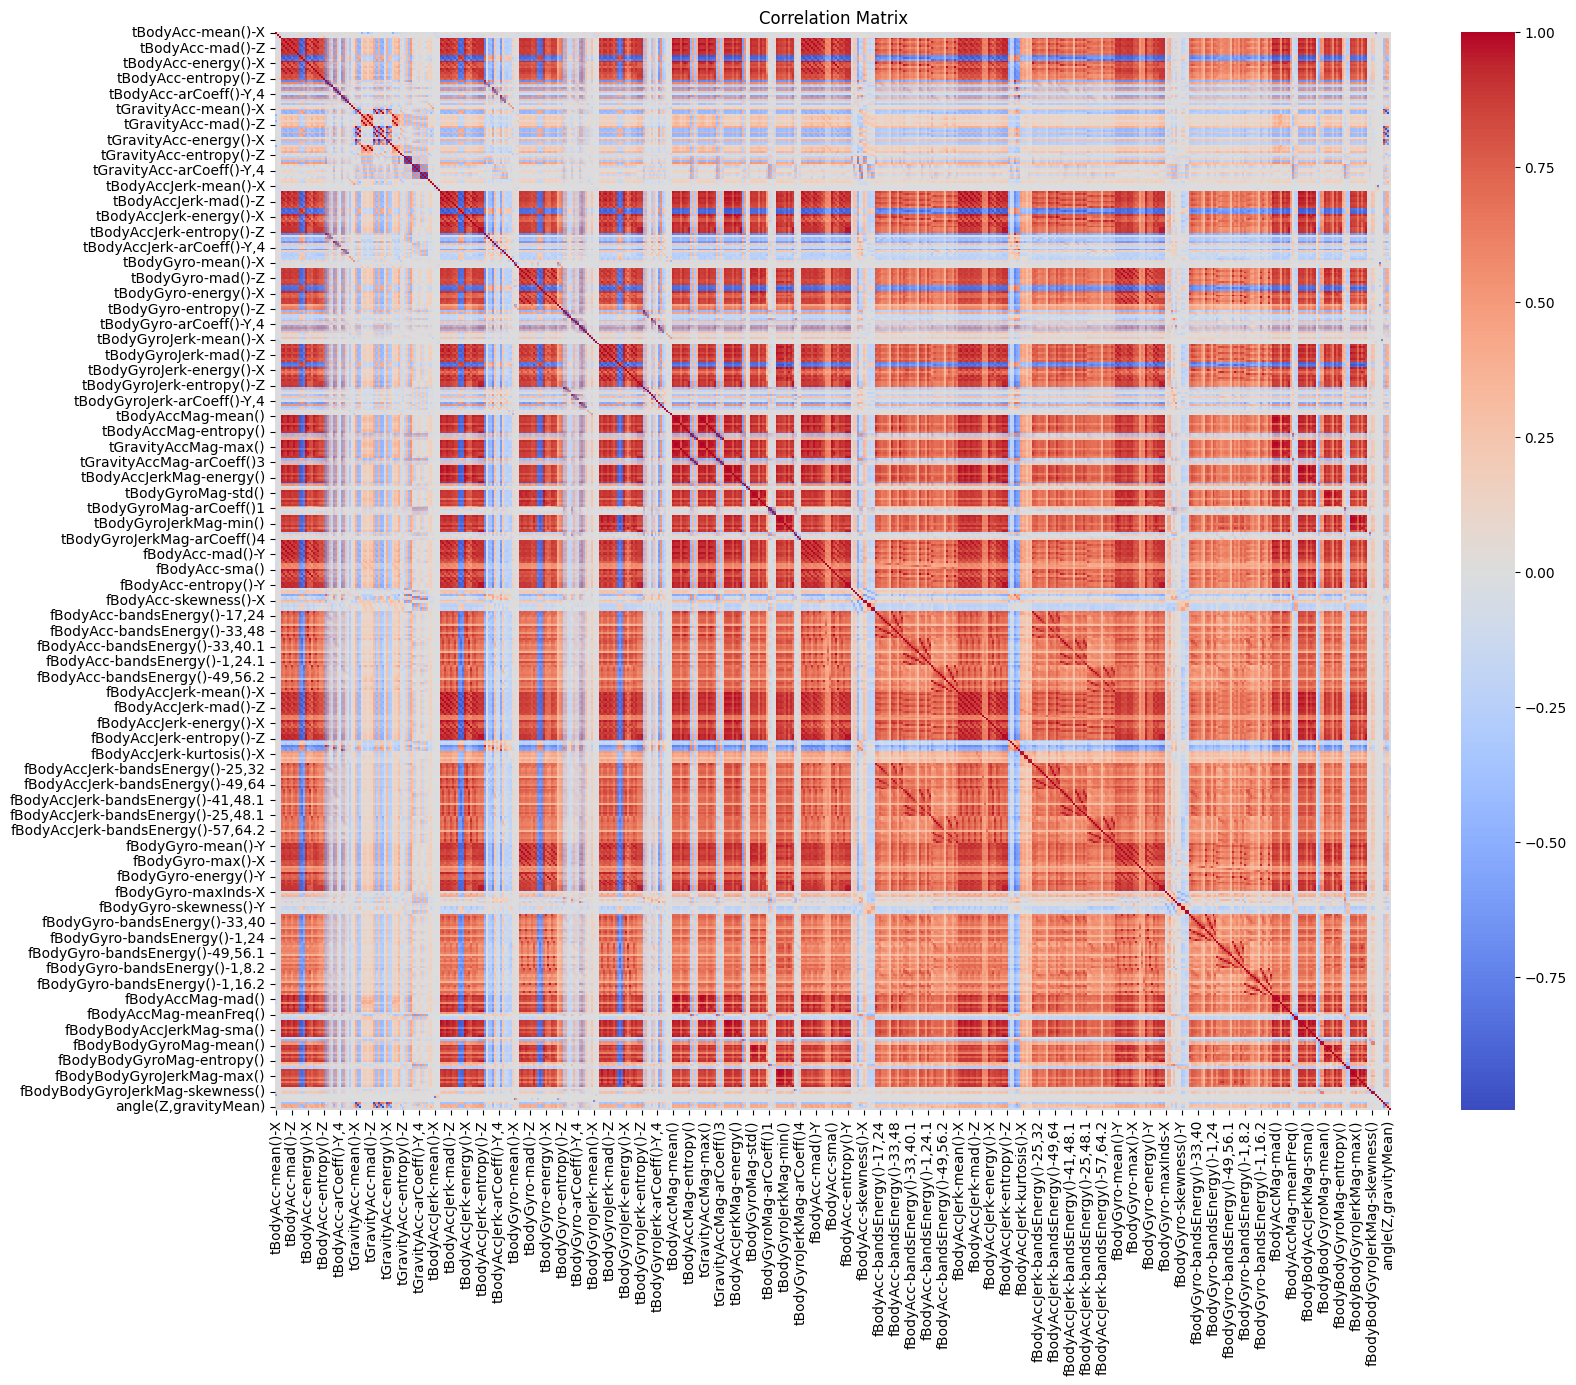

In [280]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [281]:
import pandas as pd

corr_matrix = df.corr(numeric_only=True)

print(corr_matrix)

                                      tBodyAcc-mean()-X  tBodyAcc-mean()-Y  \
tBodyAcc-mean()-X                              1.000000           0.041274   
tBodyAcc-mean()-Y                              0.041274           1.000000   
tBodyAcc-mean()-Z                             -0.129645           0.225980   
tBodyAcc-std()-X                               0.016984          -0.054264   
tBodyAcc-std()-Y                              -0.001799          -0.059066   
...                                                 ...                ...   
angle(tBodyGyroJerkMean,gravityMean)           0.049701           0.092905   
angle(X,gravityMean)                          -0.058421          -0.017138   
angle(Y,gravityMean)                           0.034220          -0.030253   
angle(Z,gravityMean)                           0.038936          -0.027410   
subject                                        0.005077           0.003163   

                                      tBodyAcc-mean()-Z  tBodyA

3. Highly Correlated Features Remove (Threshold = 0.95)

In [282]:
import numpy as np

corr_matrix = df.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print("Columns to Drop:")
print(to_drop)

Columns to Drop:
['tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X', 'tBodyAcc-min()-X', 'tBodyAcc-min()-Y', 'tBodyAcc-sma()', 'tBodyAcc-energy()-X', 'tBodyAcc-energy()-Z', 'tBodyAcc-iqr()-X', 'tBodyAcc-iqr()-Y', 'tBodyAcc-iqr()-Z', 'tGravityAcc-mad()-X', 'tGravityAcc-mad()-Y', 'tGravityAcc-mad()-Z', 'tGravityAcc-max()-X', 'tGravityAcc-max()-Y', 'tGravityAcc-max()-Z', 'tGravityAcc-min()-X', 'tGravityAcc-min()-Y', 'tGravityAcc-min()-Z', 'tGravityAcc-energy()-X', 'tGravityAcc-iqr()-X', 'tGravityAcc-iqr()-Y', 'tGravityAcc-iqr()-Z', 'tGravityAcc-arCoeff()-X,2', 'tGravityAcc-arCoeff()-X,3', 'tGravityAcc-arCoeff()-X,4', 'tGravityAcc-arCoeff()-Y,2', 'tGravityAcc-arCoeff()-Y,3', 'tGravityAcc-arCoeff()-Y,4', 'tGravityAcc-arCoeff()-Z,2', 'tGravityAcc-arCoeff()-Z,3', 'tGravityAcc-arCoeff()-Z,4', 'tBodyAccJerk-std()-X', 'tBodyAccJerk-std()-Y', 'tBodyAccJerk-mad()-X', 'tBodyAccJerk-mad()-Y', 'tBodyAccJerk-mad()-Z', 'tBodyAccJerk-max()-X', 'tBodyAccJerk-max()-Y', 'tBodyA